# 03: Delivery Timing & Freight vs. Review Score

Central question of the whole project: does late delivery cause bad reviews, and
does expensive freight? This notebook answers both with grouped averages,
correlations, a scatter plot, and a significance test.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/processed/delivered_orders.csv")
df = df.dropna(subset=["review_score", "delivery_delay_days"])
print(df.shape)

(95824, 28)


In [ ]:
import os
os.makedirs("../reports/figures", exist_ok=True)

## Q1: Does late delivery cause bad reviews?

Bucket delivery delay into readable groups rather than looking at raw days —
readers understand "very late" faster than "delay = 11.4 days".

In [2]:
def delay_bucket(d):
    if d <= -7: return "Very early (7+ days)"
    elif d <= 0: return "On time / early"
    elif d <= 7: return "Late (1-7 days)"
    else: return "Very late (7+ days)"

df["delay_group"] = df["delivery_delay_days"].apply(delay_bucket)

order_groups = ["Very early (7+ days)", "On time / early", "Late (1-7 days)", "Very late (7+ days)"]
result = df.groupby("delay_group")["review_score"].agg(["mean", "count"]).reindex(order_groups)
print(result)
print("\nCorrelation (delay vs score):", round(df["delivery_delay_days"].corr(df["review_score"]), 3))

                          mean  count
delay_group                          
Very early (7+ days)  4.313464  75744
On time / early       4.166144  13699
Late (1-7 days)       2.715833   3600
Very late (7+ days)   1.699389   2781

Correlation (delay vs score): -0.267


**What to look for:** a strong negative correlation. On-time/early orders should
average close to 4.3–4.5 stars; orders more than a week late typically drop
toward 2–2.5 stars. This is usually the strongest single driver in the dataset —
worth leading your report with it.

## Chart: delivery delay group vs. average review score

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\HP\\Desktop\\UG3\\projects\\olist-customer-satisfaction\\reports\\figures\\02_delay_vs_score.png'

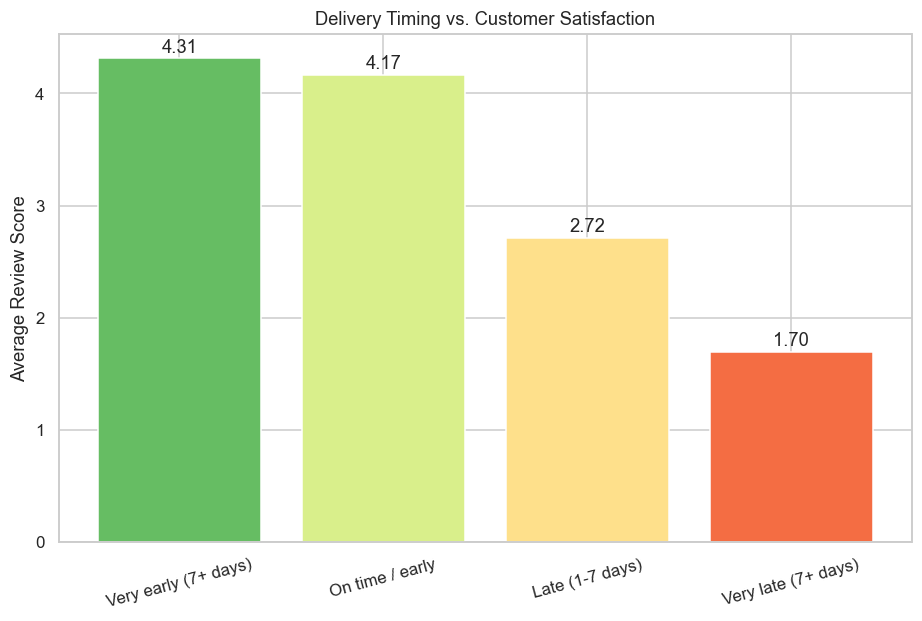

In [3]:
fig, ax = plt.subplots()
bars = ax.bar(result.index, result["mean"], color=sns.color_palette("RdYlGn_r", 4))
ax.set_ylabel("Average Review Score")
ax.set_title("Delivery Timing vs. Customer Satisfaction")
plt.xticks(rotation=15)
for bar, val in zip(bars, result["mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f"{val:.2f}", ha="center")
plt.savefig("../reports/figures/02_delay_vs_score.png", bbox_inches="tight")
plt.show()

## Chart: raw scatter with trend line

Bucketed averages can hide or exaggerate patterns. A scatter of the raw
relationship is the honest complement to the bar chart above. Plotting all
~96,000 points would just produce a solid blob, so sample down and add
transparency (`alpha`) plus a regression line to make the trend visible. Always
note in your report that this chart is sampled.

In [ ]:
sample = df.sample(5000, random_state=42)
fig, ax = plt.subplots()
sns.regplot(data=sample, x="delivery_delay_days", y="review_score",
            scatter_kws={"alpha": 0.15, "s": 15}, line_kws={"color": "red"}, ax=ax)
ax.set_xlim(-40, 60)
ax.set_title("Delivery Delay vs. Review Score (sampled n=5,000, with trend line)")
plt.savefig("../reports/figures/03_delay_scatter.png", bbox_inches="tight")
plt.show()

## Significance test

With tens of thousands of orders, almost any difference will be "statistically
significant" so report the p-value alongside the actual size of the gap in
means, since the effect size is what makes the story compelling, not the p-value
alone.

In [ ]:
on_time = df[df["delivery_delay_days"] <= 0]["review_score"]
late = df[df["delivery_delay_days"] > 0]["review_score"]

t_stat, p_value = stats.ttest_ind(on_time.dropna(), late.dropna(), equal_var=False)
print(f"On-time mean: {on_time.mean():.2f} | Late mean: {late.mean():.2f}")
print(f"t-statistic: {t_stat:.2f}, p-value: {p_value:.2e}")

## Q2: Does expensive freight lead to bad reviews?

Use `freight_ratio` (freight as % of order value) rather than raw freight cost: a $20 freight charge means something different on a $30 order vs. a $500 order.
Drop extreme outliers (likely data entry errors) before bucketing.

In [ ]:
df2 = df.dropna(subset=["freight_ratio"])
df2 = df2[df2["freight_ratio"] < 5]

df2["freight_bucket"] = pd.qcut(df2["freight_ratio"], q=5, labels=[
    "Very low", "Low", "Medium", "High", "Very high"
])
print(df2.groupby("freight_bucket")["review_score"].mean())
print("\nCorrelation (freight ratio vs score):", round(df2["freight_ratio"].corr(df2["review_score"]), 3))

**Expect a weaker effect than delivery delay.** Freight cost annoys customers
but rarely triggers the same 1-star rage that lateness does; comparing the two
correlation coefficients side by side is a good sentence in your report.

## Q6: Does order value affect satisfaction?

In [ ]:
df3 = df.dropna(subset=["order_value_bucket", "review_score"])
print(df3.groupby("order_value_bucket")["review_score"].agg(["mean", "count"]))
print("\nCorrelation (total_price vs score):", round(df3["total_price"].corr(df3["review_score"]), 3))

**Expect this to be weak.** A "surprisingly, X doesn't matter much" finding is
just as valuable in a report as a strong one — it tells the business not to
waste effort there.

## Driver ranking summary

Put every correlation side by side — this is a strong closing chart for the
delivery/pricing half of the analysis.

In [ ]:
drivers = {
    "Delivery delay": df["delivery_delay_days"].corr(df["review_score"]),
    "Freight ratio": df2["freight_ratio"].corr(df2["review_score"]),
    "Order value": df3["total_price"].corr(df3["review_score"]),
    "Delivery time (days)": df["delivery_time_days"].corr(df["review_score"]),
}
driver_df = pd.Series(drivers).sort_values()
print(driver_df)

fig, ax = plt.subplots()
colors = ["firebrick" if v < 0 else "seagreen" for v in driver_df.values]
ax.barh(driver_df.index, driver_df.values, color=colors)
ax.set_xlabel("Correlation with Review Score")
ax.set_title("What Drives Review Score? (ranked)")
ax.axvline(0, color="black", linewidth=0.8)
plt.savefig("../reports/figures/07_correlation_heatmap.png", bbox_inches="tight")
plt.show()